## AWS EC2 with Boto3 Python

https://boto3.amazonaws.com/v1/documentation/api/latest/guide/quickstart.html

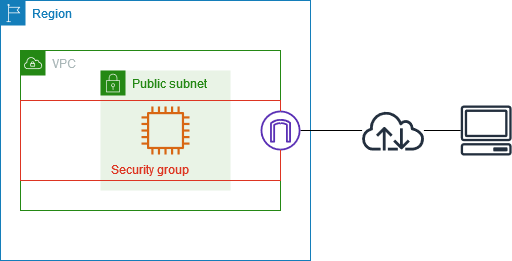

Amazon Elastic Compute Cloud (Amazon EC2) is a web service that provides resizeable computing capacity in servers in Amazon's data centers—that you use to build and host your software systems.

- Create Key-Pair for Secure Connection
- Create an Amazon EC2 instance
    - test with ip address in browser
    - test with ssh connection
- Create Security Group and add rules to it
- Attaching and Detaching Security Groups to Amazon EC2 instances
    - test with ip address in browser
    - test with ssh connection
- Start, Stop and Delete Amazon EC2 instances

## Create Key-Pair for Secure Connection

In [4]:
import boto3
from botocore.exceptions import ClientError
import os
from pathlib import Path
from curses import keyname

In [5]:
ec2 = boto3.client('ec2')

ec2.describe_instances()

{'Reservations': [{'Groups': [],
   'Instances': [{'AmiLaunchIndex': 0,
     'ImageId': 'ami-073d9221f657bc5ff',
     'InstanceId': 'i-0ecbbd5c4d73259a7',
     'InstanceType': 't3.large',
     'KeyName': 'omixec',
     'LaunchTime': datetime.datetime(2026, 3, 4, 19, 6, 55, tzinfo=tzutc()),
     'Monitoring': {'State': 'disabled'},
     'Placement': {'AvailabilityZone': 'us-east-1d',
      'GroupName': '',
      'Tenancy': 'default'},
     'PrivateDnsName': '',
     'ProductCodes': [],
     'PublicDnsName': '',
     'State': {'Code': 48, 'Name': 'terminated'},
     'StateTransitionReason': 'User initiated (2026-03-04 19:26:07 GMT)',
     'Architecture': 'x86_64',
     'BlockDeviceMappings': [],
     'ClientToken': '6db3c57e-8619-44f1-8044-b4d5dcb34e7c',
     'EbsOptimized': False,
     'EnaSupport': True,
     'Hypervisor': 'xen',
     'NetworkInterfaces': [],
     'RootDeviceName': '/dev/xvda',
     'RootDeviceType': 'ebs',
     'SecurityGroups': [],
     'StateReason': {'Code': 'Clien

In [6]:
# Function to set credentials folder and write our key into the folder
# Inpur your key name

def create_and_save_key(key_name, folder_path="key-pairs"):
    # 1. Ensure the directory exists
    # Path.mkdir(parents=True) creates the folder (and subfolders) if they don't exist
    Path(folder_path).mkdir(parents=True, exist_ok=True)
    
    file_path = os.path.join(folder_path, f"{key_name}.pem")

    try:
        print(f"🚀 Attempting to create key: {key_name}...")
        resp = ec2.create_key_pair(KeyName=key_name)
        
        # 2. Write the PEM content to the file
        with open(file_path, 'w') as f:
            f.write(resp['KeyMaterial'])
            
        # 3. Set restrictive permissions (Required for SSH on Linux/Mac)
        # 0o400 means Read-only for the owner
        os.chmod(file_path, 0o400)
        
        print(f"✅ Success! Key saved to: {file_path}")
        return resp

    except ClientError as e:
        if e.response['Error']['Code'] == 'InvalidKeyPair.Duplicate':
            print(f"⚠️  Key '{key_name}' already exists in AWS.")
            choice = input("Enter a new name to try again (or 'q' to quit): ")
            if choice.lower() != 'q':
                return create_and_save_key(choice, folder_path)
        else:
            print(f"❌ AWS Error: {e}")
        return None

# Run it
key_result = create_and_save_key('omixec')

🚀 Attempting to create key: omixec...
✅ Success! Key saved to: key-pairs/omixec.pem


## Create an Amazon EC2 instance

In [22]:
ec2.describe_instances()

response = ec2.run_instances(
    ImageId = 'ami-0f3caa1cf4417e51b',
    MinCount=1,
    MaxCount=1,
    InstanceType='t3.micro',
    KeyName='omixec',
    BlockDeviceMappings=[
        {
            "DeviceName": "/dev/xvda",
            'Ebs':{
                'DeleteOnTermination': True,
                'VolumeSize': 20
            }
        }
    ]

)

In [23]:
ec2.describe_instances()

{'Reservations': [{'Groups': [],
   'Instances': [{'AmiLaunchIndex': 0,
     'ImageId': 'ami-0f3caa1cf4417e51b',
     'InstanceId': 'i-0aa31aa20d049d327',
     'InstanceType': 't3.micro',
     'KeyName': 'omixec',
     'LaunchTime': datetime.datetime(2026, 3, 3, 23, 43, 56, tzinfo=tzutc()),
     'Monitoring': {'State': 'disabled'},
     'Placement': {'AvailabilityZone': 'us-east-1a',
      'GroupName': '',
      'Tenancy': 'default'},
     'PrivateDnsName': 'ip-172-31-4-105.ec2.internal',
     'PrivateIpAddress': '172.31.4.105',
     'ProductCodes': [],
     'PublicDnsName': 'ec2-100-52-167-194.compute-1.amazonaws.com',
     'PublicIpAddress': '100.52.167.194',
     'State': {'Code': 16, 'Name': 'running'},
     'StateTransitionReason': '',
     'SubnetId': 'subnet-07f5cdb61467f347f',
     'VpcId': 'vpc-028da302657b775e0',
     'Architecture': 'x86_64',
     'BlockDeviceMappings': [{'DeviceName': '/dev/xvda',
       'Ebs': {'AttachTime': datetime.datetime(2026, 3, 3, 23, 43, 57, tzinfo

## Create Security Group and add rules to it
- Security groups control inbound and outbound traffic of the EC2 instance network interface.
- every EC2 instance must have at least one Security Group associated with it. If no Security Group has been specified during the EC2 instance launch, the default Security Group of the default VPC is associated with the instance.

In [25]:
response = ec2.describe_security_groups()

response = ec2.create_security_group(
    GroupName = 'omixec-test',
    Description = "Security group for testing"
)

In [26]:
security_group_id = response['GroupId']
security_group_id

'sg-02d7929819d6ec689'

In [27]:
# ip, port, traffic type
response = ec2.authorize_security_group_ingress(
    GroupId = security_group_id,
    IpPermissions=[
        {
            'IpProtocol': 'tcp',
            'FromPort': 22,
            'ToPort': 22,
            'IpRanges': [{'CidrIp': '0.0.0.0/0'}]
        },
        {
            'IpProtocol': 'tcp',
            'FromPort': 80,
            'ToPort': 80,
            'IpRanges': [{'CidrIp': '0.0.0.0/0'}]
        }
    ]
)

In [28]:
response = ec2.describe_instances()

instrance_id = response['Reservations'][0]['Instances'][0]['InstanceId']
instrance_id, security_group_id

('i-0aa31aa20d049d327', 'sg-02d7929819d6ec689')

In [29]:
old_gid = response['Reservations'][0]['Instances'][0]['SecurityGroups'][0]['GroupId']

In [30]:
ec2.modify_instance_attribute(InstanceId=instrance_id, Groups=[security_group_id])

{'ResponseMetadata': {'RequestId': 'dcabb1d4-769d-4767-b0cd-9f890922a31d',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': 'dcabb1d4-769d-4767-b0cd-9f890922a31d',
   'cache-control': 'no-cache, no-store',
   'strict-transport-security': 'max-age=31536000; includeSubDomains',
   'content-type': 'text/xml;charset=UTF-8',
   'content-length': '235',
   'date': 'Tue, 03 Mar 2026 23:46:12 GMT',
   'server': 'AmazonEC2'},
  'RetryAttempts': 0}}

In [31]:
ec2.modify_instance_attribute(InstanceId=instrance_id, Groups=[old_gid, security_group_id])

{'ResponseMetadata': {'RequestId': '3b045ebd-66ee-4918-9615-5a783a2f5d28',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '3b045ebd-66ee-4918-9615-5a783a2f5d28',
   'cache-control': 'no-cache, no-store',
   'strict-transport-security': 'max-age=31536000; includeSubDomains',
   'content-type': 'text/xml;charset=UTF-8',
   'content-length': '235',
   'date': 'Tue, 03 Mar 2026 23:46:54 GMT',
   'server': 'AmazonEC2'},
  'RetryAttempts': 0}}

## Start, Stop and Delete Amazon EC2 instances

In [32]:
# status -> running, stopped, terminated, pending etc.

import time

def wait_for_status(instance_id, target_status):
    while True:
        response = ec2.describe_instances(InstanceIds=instance_id)

        status = response['Reservations'][0]['Instances'][0]['State']['Name']

        if status == target_status:
            print("Instance is in {} state".format(target_status))
            break
        
        time.sleep(10)


def start_instances(instance_id):
    print("EC2 Instance Start")
    ec2.start_instances(InstanceIds=instance_id)

    wait_for_status(instance_id, 'running')

start_instances([instrance_id])


EC2 Instance Start
Instance is in running state


In [ ]:
def stop_instances(instance_id):
    print("EC2 Instance Stop")
    ec2.stop_instances(InstanceIds=instance_id)

    wait_for_status(instance_id, 'stopped')

stop_instances([instrance_id])

In [33]:
def terminate_instances(instance_id):
    print("EC2 Instance Termination")
    ec2.terminate_instances(InstanceIds=instance_id)

    wait_for_status(instance_id, 'terminated')

terminate_instances([instrance_id])

EC2 Instance Termination
Instance is in terminated state
